Загрузка датасета

Обучение XGBoost

Обучение LightGBM

РЕЗУЛЬТАТЫ ДЛЯ ТАБЛИЦ
XGBoost Время: 6.3738 сек | Accuracy: 0.9996 | F1: 0.9340
LightGBM Время: 4.9527 сек | Accuracy: 0.9922 | F1: 0.6076

Обучение Оптимизированного LightGBM (Улучшение)
LightGBM Opt Время: 10.6724 сек | Accuracy: 0.9996 | F1: 0.9357


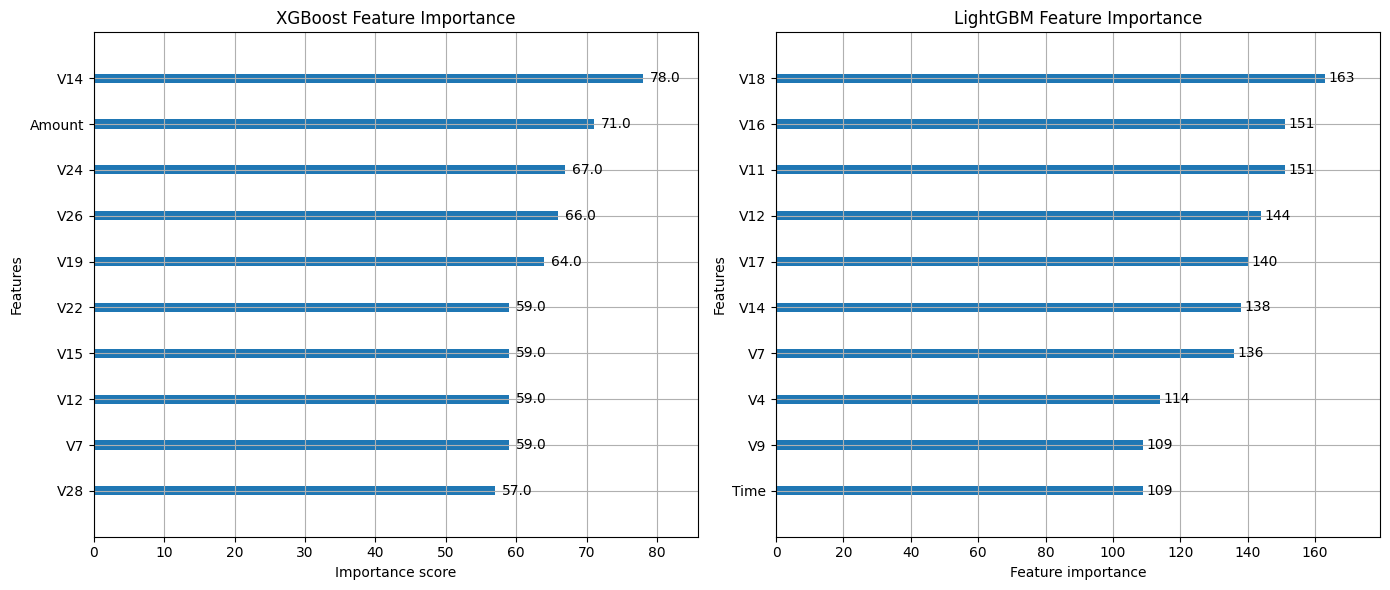

In [1]:
import time
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Загрузка датасета")
data = fetch_openml('CreditCardFraudDetection', version=1, as_frame=True, parser='auto')
X, y = data.data, data.target

X = X.select_dtypes(include=['int64', 'float64']).fillna(0)
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nОбучение XGBoost")
start_time = time.time()
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
xgb_preds = xgb_model.predict(X_test)

print("\nОбучение LightGBM")
start_time = time.time()
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time
lgb_preds = lgb_model.predict(X_test)

print("\nРЕЗУЛЬТАТЫ ДЛЯ ТАБЛИЦ")
print(f"XGBoost  Время: {xgb_time:.4f} сек | Accuracy: {accuracy_score(y_test, xgb_preds):.4f} | F1: {f1_score(y_test, xgb_preds, average='macro'):.4f}")
print(f"LightGBM Время: {lgb_time:.4f} сек | Accuracy: {accuracy_score(y_test, lgb_preds):.4f} | F1: {f1_score(y_test, lgb_preds, average='macro'):.4f}")

print("\nОбучение Оптимизированного LightGBM (Улучшение)")
start_time = time.time()

lgb_opt = lgb.LGBMClassifier(
    random_state=42,
    max_depth=7,
    learning_rate=0.05,
    n_estimators=200,
    reg_lambda=1.0,
    verbose=-1
)
lgb_opt.fit(X_train, y_train)
lgb_opt_time = time.time() - start_time
lgb_opt_preds = lgb_opt.predict(X_test)
print(f"LightGBM Opt Время: {lgb_opt_time:.4f} сек | Accuracy: {accuracy_score(y_test, lgb_opt_preds):.4f} | F1: {f1_score(y_test, lgb_opt_preds, average='macro'):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
xgb.plot_importance(xgb_model, max_num_features=10, ax=ax[0], title="XGBoost Feature Importance")
lgb.plot_importance(lgb_model, max_num_features=10, ax=ax[1], title="LightGBM Feature Importance")
plt.tight_layout()
plt.savefig('feature_importance.png')